# CS106 - Sesión 10 | Notebook 48: Log-Rank Test ⚖️

Mientras que Kaplan-Meier nos da una estimación puramente visual, el **Log-Rank Test** (Prueba de Mantel-Cox) es la herramienta matemática formal para comparar las curvas de supervivencia de dos o más grupos.

### ¿Cómo funciona internamente?
La prueba analiza cada día del seguimiento, cuenta cuántos eventos ocurrieron en cada grupo y los compara con el número de eventos que *esperaríamos* ver si ambos grupos se comportaran exactamente igual.

* **Hipótesis Nula ($H_0$):** No hay diferencia en la velocidad o probabilidad de hospitalización entre los grupos.
* **Valor p < 0.05:** Rechazamos $H_0$ y concluimos científicamente que al menos un grupo tiene un riesgo de evento significativamente distinto.

## 1. ¿Influye el Sexo en el Tiempo al Evento?
Utilizaremos la función `survdiff()` de la librería `survival`. Evaluaremos de forma preliminar si el sexo biológico determina qué tan rápido ingresa un paciente.

In [ ]:
library(tidyverse)
library(survival)

# Cargamos los datos
datos <- read_csv("cohorte_survival.csv")

# Ejecutamos la prueba Log-Rank por Sexo
prueba_logrank <- survdiff(Surv(dias_hasta_hospitalizacion, hospitalizado) ~ sexo, data = datos)

# Mostramos el reporte completo
print(prueba_logrank)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 200 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): sexo
dbl (7): paciente_id, edad, estatura_m, peso_kg, glucosa_mgdl, hospitalizado...
lgl (3): diabetes, hipertension, obesidad

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Call:
survdiff(formula = Surv(dias_hasta_hospitalizacion, hospitalizado) ~ 
    sexo, data = datos)

              N Observed Expected (O-E)^2/E (O-E)^2/V
sexo=Hombre  95       45     50.6     0.617      1.25
sexo=Mujer  105       56     50.4     0.619      1.25

 Chisq= 1.2  on 1 degrees of freedom, p= 0.3 


## 2. Lectura de Resultados Estadísticos
En la tabla que arrojó la celda anterior verás reflejadas cuatro métricas fundamentales:
* **N:** Número de pacientes analizados por grupo.
* **Observed (O):** El número real de eventos que ocurrieron en la cohorte.
* **Expected (E):** Los eventos teóricos calculados bajo el supuesto de que los grupos son idénticos.
* **p-value (chisq):** Ubicado al final del reporte, es el dato decisivo para tu conclusión.

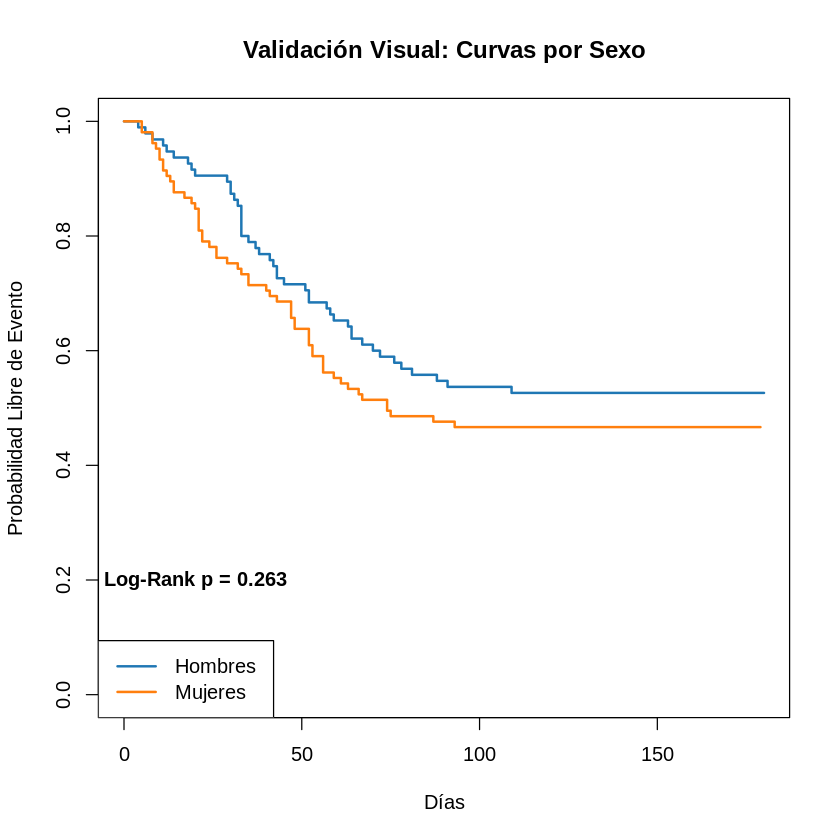

In [ ]:
# Generamos el ajuste visual rápido para complementar la prueba estadística
ajuste_test <- survfit(Surv(dias_hasta_hospitalizacion, hospitalizado) ~ sexo, data = datos)

plot(ajuste_test,
     col = c("#1f77b4", "#ff7f0e"),
     lwd = 2,
     main = "Validación Visual: Curvas por Sexo",
     xlab = "Días", ylab = "Probabilidad Libre de Evento")

legend("bottomleft", legend = c("Hombres", "Mujeres"),
       col = c("#1f77b4", "#ff7f0e"), lty = 1, lwd = 2)

# Añadimos una anotación textual del resultado observado
text(x = 20, y = 0.2, labels = "Log-Rank p = 0.263", col = "black", font = 2)

## 3. Análisis Integral: Impacto de la Diabetes
Ahora evaluaremos una condición de alta relevancia clínica. ¿Determina la presencia de **Diabetes** una diferencia estadísticamente significativa en el tiempo libre de hospitalización?

**Tu misión:**
1. Ejecuta la prueba de Log-Rank comparando las curvas entre pacientes con y sin diabetes.
2. Extrae el valor **p** exacto calculado.
3. Identifica qué grupo experimentó un número de eventos observados mucho mayor de lo esperado por el modelo.

In [ ]:
# --- 1. CÓDIGO INTEGRAL DE ANÁLISIS ---
# Ejecutamos el test estadístico contrastando la variable 'diabetes'
test_diabetes <- survdiff(Surv(dias_hasta_hospitalizacion, hospitalizado) ~ diabetes, data = datos)
print(test_diabetes)

# Proceso técnico para extraer y mostrar el valor p exacto de la prueba de Chi-cuadrada
p_val <- 1 - pchisq(test_diabetes$chisq, length(test_diabetes$n) - 1)
cat("\nValor p exacto calculado para Diabetes:", p_val, "\n")


# --- 2. SECCIÓN DE RESPUESTAS (RELLENA LOS VALORES REVISANDO LA CONSOLA) ---

# r1: Escribe el valor p observado (si es extremadamente bajo, puedes colocar 0.0000)
r1_p_valor <- 0.0000

# r2: ¿Existe una diferencia estadísticamente significativa entre las curvas (p < 0.05)?
# (Escribe TRUE o FALSE)
r2_es_significativo <- TRUE

# r3: ¿Qué grupo tiene más eventos Reales (Observed) de los Esperados (Expected)?
# (Escribe "TRUE" para los que tienen diabetes o "FALSE" para los que no)
r3_grupo_clave <- "TRUE"


# --- 3. CONSTRUCCIÓN DEL DATA FRAME DE EVALUACIÓN ---
df_respuesta <- data.frame(
  item = c("p_valor", "significancia", "grupo_mas_afectado"),
  valor = c(as.character(r1_p_valor),
            as.character(r2_es_significativo),
            r3_grupo_clave)
)

print(df_respuesta)

Call:
survdiff(formula = Surv(dias_hasta_hospitalizacion, hospitalizado) ~ 
    diabetes, data = datos)

                 N Observed Expected (O-E)^2/E (O-E)^2/V
diabetes=FALSE 105       36     62.5      11.2      30.3
diabetes=TRUE   95       65     38.5      18.3      30.3

 Chisq= 30.3  on 1 degrees of freedom, p= 4e-08 

Valor p exacto calculado para Diabetes: 3.660787e-08 
                item valor
1            p_valor     0
2      significancia  TRUE
3 grupo_mas_afectado  TRUE


In [ ]:
# Ejecuta para guardar tu avance
source("utilidades.r")
guardar_48(df_respuesta)